In [ ]:
###
    # This code plot the vertical profile of soil water content. 
    # 1. Read soil water content data.
    # 2. Calculate water density (kg/m³) and interpolate onto a uniform vertical grid.
    # 3. Mask grid cells within permafrost regions.
    # 4. Calculate multi-year mean and area-weighted average within the region.
    # 5. Plot the vertical profile.
    # 6. Output: Figure S5.
###

In [1]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import os
warnings.filterwarnings('ignore')

In [2]:
def area_weight_mean(data2D, lat, lon):
    """
    Calculate the area-weighted mean of 2D data, accounting for grid cell areas.
    
    Parameters:
    data2D: ndarray
        Variable for area-weighted averaging, with shape [lat, lon].
    lat: ndarray
        Latitude array, 1D, in degrees.
    lon: ndarray
        Longitude array, 1D, in degrees.
    
    Returns:
    float
        Area-weighted mean of the data.
    """
    # Convert latitude to radians
    rad = np.pi / 180.0
    lat_rad = lat * rad

    # Calculate latitude and longitude resolution
    re = 6371220.0  # Earth radius (in meters)
    dlon = np.abs(lon[1] - lon[0]) * rad  # Longitude resolution (in radians)
    dlat = np.abs(lat[1] - lat[0]) * rad  # Latitude resolution (in radians)

    # Calculate the area of each grid cell
    sin_lat1 = np.sin(lat_rad + dlat / 2)
    sin_lat2 = np.sin(lat_rad - dlat / 2)
    grid_areas = (re ** 2) * dlon * (sin_lat1 - sin_lat2)[:, np.newaxis]  # (lat, lon)

    # Calculate weighted mean
    valid_mask = ~np.isnan(data2D)  # Valid data mask
    weighted_sum = np.nansum(data2D * grid_areas * valid_mask)  # Sum of weighted values
    total_weight = np.nansum(grid_areas * valid_mask)  # Sum of weights

    # If total weight is 0 (all NaN), return NaN
    if total_weight == 0:
        return np.nan

    return weighted_sum / total_weight

In [ ]:
# Create empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []

models = ["CESM2","CESM2-FV2", "CESM2-WACCM",
          "CNRM-CM6-1", "CNRM-ESM2-1",
          "GFDL-ESM4", "NorESM2-LM", "NorESM2-MM", 
          "TaiESM1"
          ]

# Data folder paths
data_folder = "../Data/cmip6_mrsfl/"
data_folder2 = "../Data/cmip6_mrsll/"
probability_file = "../Data/probability_lt_threshold_320.nc"

# Read probability threshold data
ds_prob = xr.open_dataset(probability_file)
ds_prob = ds_prob.sel(lon=slice(0, 186))

# Select grid points with probability_lt_threshold > 0
mask = ds_prob['probability_lt_threshold'] > 0
# Create grid for probability data
lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)

# Loop over each model
for fi, model in enumerate(models):
        
    filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds = xr.open_dataset(filepath)
    ds = ds.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds = ds.isel(time=year_mask)
    except:
        ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))

    filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds2 = xr.open_dataset(filepath2)
    ds2 = ds2.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds2.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds2 = ds2.isel(time=year_mask)
    except:
        ds2 = ds2.sel(time=slice('1982-01-01', '2014-12-31'))

    total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

    try:
        depth = ds['depth']
        depth_bnds = ds['depth_bnds']
        thickness = np.empty(len(depth))
        for i in range(len(depth)):
            thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
    except:
        try:
            depth = ds['sdepth']
            depth_bnds = ds['sdepth_bounds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            zhalf_soil = ds['zhalf_soil'].values
            thickness = np.diff(zhalf_soil)         # Calculate thickness
    #print(thickness)
    # Calculate water density (kg/m³)
    density_water_content = total / thickness[None, :, None, None]

    # Create new depth coordinate
    new_depths = np.arange(0.1, 10.1, 0.1)

    # Interpolation
    try:
        density_water_content_interp = density_water_content.interp(
            depth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    except:
        density_water_content_interp = density_water_content.interp(
            sdepth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    # Remove negative values
    density_water_content_interp = density_water_content_interp.clip(min=0)

    # Create grid for soil data
    lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
    
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
    
    # Interpolate mask to soil data grid
    mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                            mask.values.ravel(),
                            (lon_soil.ravel(), lat_soil.ravel()), 
                            method='nearest')
    
    mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

    # Create mask array with same dimensions as soil data
    mask_da = xr.DataArray(mask_interp, 
                            coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                            dims=['lat', 'lon'])

    # Apply mask to filter data
    density_water_masked = density_water_content_interp.where(mask_da, drop=False)

    # Apply land mask
    sftlf = xr.open_dataset(glob.glob(f'../Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
    land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
    if np.nanmax(land_mask_aligned) == 100:
        land_mask = land_mask_aligned > 50
    else:
        land_mask = land_mask_aligned > 0.5

    density_water_masked = density_water_masked.where(land_mask)
    # Calculate multi-year mean
    mean_yearly_range = density_water_masked.mean(dim='time')

    # ===============================
    # Area weighting (per depth level)
    # ===============================
    lat = mean_yearly_range.lat.values
    lon = mean_yearly_range.lon.values

    depth_profile_weighted = np.zeros(len(new_depths))

    for i in range(len(new_depths)):
        data2D = mean_yearly_range[i,:,:].values  # (lat, lon)
        depth_profile_weighted[i] = area_weight_mean(data2D, lat, lon)

    depth_profiles_all_models.append(depth_profile_weighted)

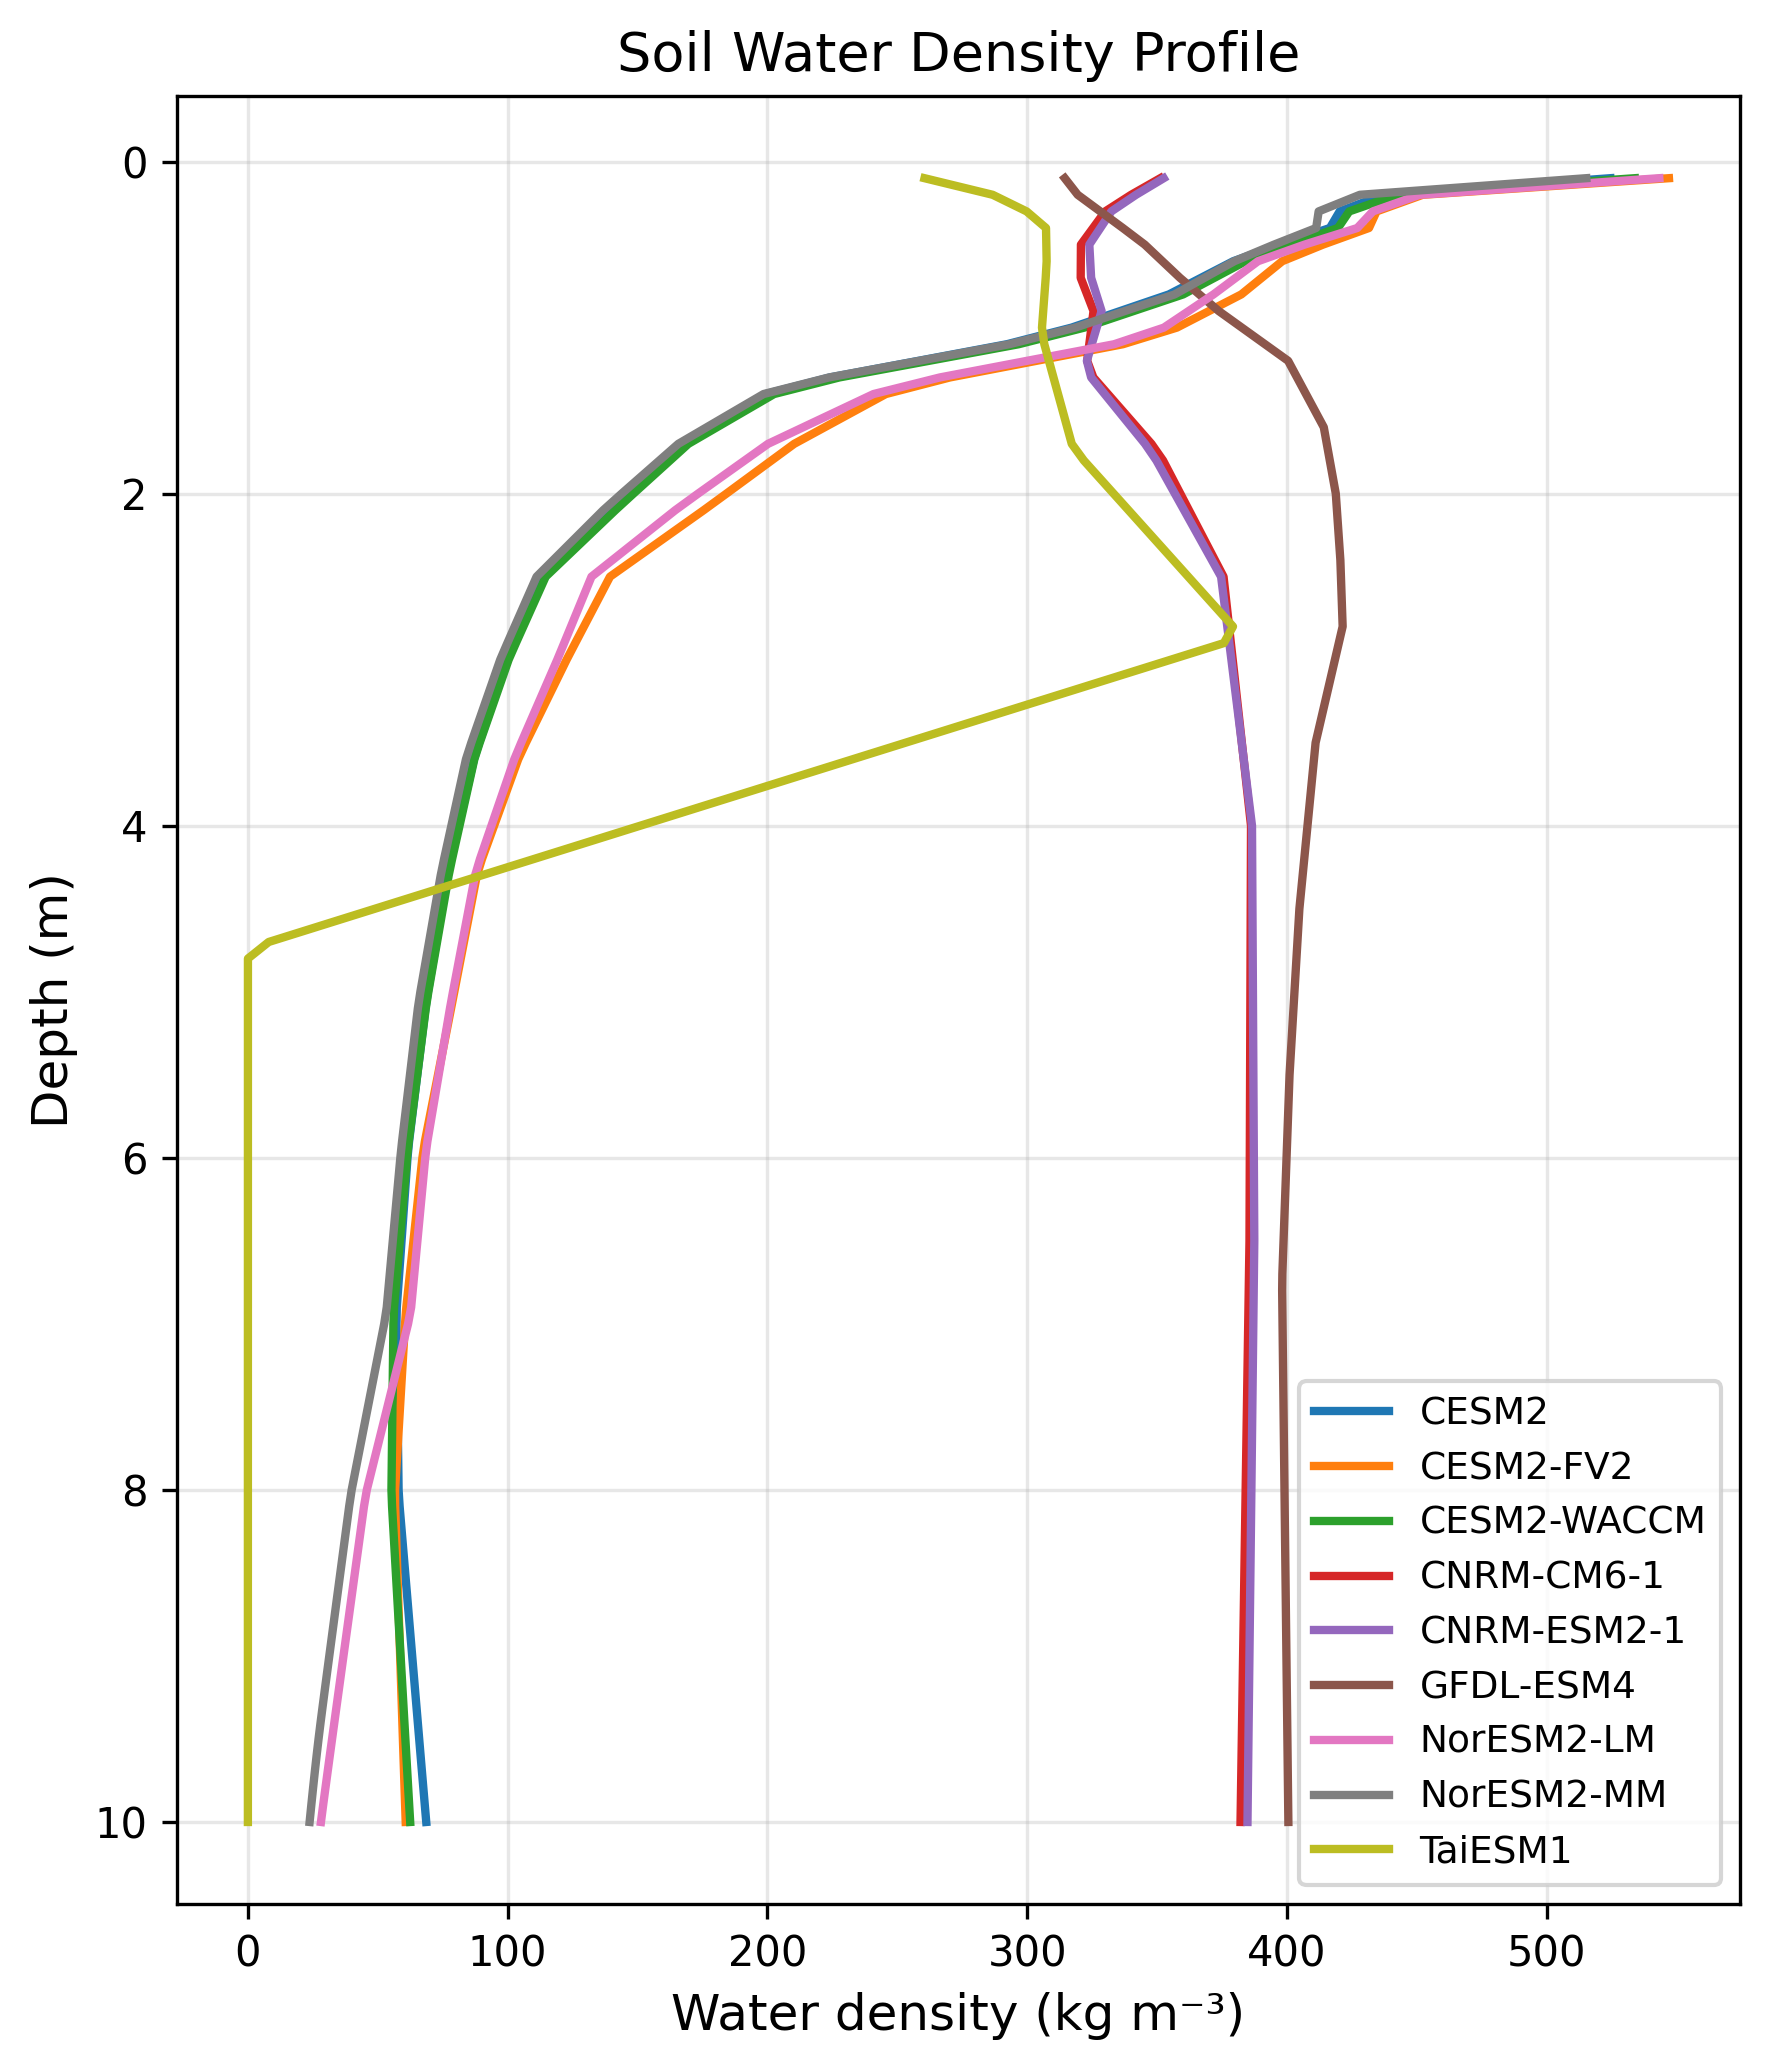

In [4]:
fig = plt.figure(figsize=(6, 7), dpi=300)

for i, model in enumerate(models):
    plt.plot(depth_profiles_all_models[i], new_depths, label=model, linewidth=2)

# Depth increasing downward
plt.gca().invert_yaxis()

# Axes labels
plt.xlabel('Water density (kg m⁻³)', fontsize=12)
plt.ylabel('Depth (m)', fontsize=12)

# Legend
plt.legend(fontsize=9, ncol=1)

# Grid
plt.grid(alpha=0.3)

# Title
plt.title('Soil Water Density Profile', fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig("../Figures/FigureS5.png", bbox_inches='tight',dpi=300)